In [2]:
import pandas as pd



In [3]:
df = pd.read_csv('datauber.csv')
df.head(10)

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194.0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199.0,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355.0,2009-08-24 21:45:00.00000061,12.9,NaN,-74.005043,40.740770,NaN,40.772647,1.0
3,25894730.0,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,NaN,-73.965316,40.803349,3.0
4,17610152.0,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,NaN,40.744085,-73.973082,NaN,5.0
5,44470845.0,2011-02-12 02:27:09.0000006,4.9,2011-02-12 02:27:09 UTC,-73.969019,40.755910,-73.969019,40.755910,1.0
6,48725865.0,2014-10-12 07:04:00.0000002,24.5,2014-10-12 07:04:00 UTC,NaN,40.693965,-73.871195,40.774297,5.0
7,44195482.0,2012-12-11 13:52:00.00000029,2.5,2012-12-11 13:52:00 UTC,0.000000,0.000000,0.000000,0.000000,1.0
8,15822268.0,2012-02-17 09:32:00.00000043,9.7,2012-02-17 09:32:00 UTC,-73.975187,40.745767,-74.002720,40.743537,1.0
9,50611056.0,2012-03-29 19:06:00.000000273,12.5,2012-03-29 19:06:00 UTC,-74.001065,40.741787,-73.963040,NaN,1.0


In [4]:
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44377 entries, 0 to 44376
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         42243 non-null  float64
 1   key                42143 non-null  object 
 2   fare_amount        42217 non-null  float64
 3   pickup_datetime    42094 non-null  object 
 4   pickup_longitude   42183 non-null  float64
 5   pickup_latitude    42130 non-null  float64
 6   dropoff_longitude  42183 non-null  float64
 7   dropoff_latitude   42119 non-null  float64
 8   passenger_count    42159 non-null  float64
dtypes: float64(7), object(2)
memory usage: 3.0+ MB


In [6]:
df = df.drop(columns=['Unnamed: 0', 'key', 'fare_amount', 
                      'dropoff_longitude', 'dropoff_latitude', 
                      'passenger_count'])

In [7]:
df.head()

,pickup_datetime,pickup_longitude,pickup_latitude
0,2015-05-07 19:52:06 UTC,-73.999817,40.738354
1,2009-07-17 20:04:56 UTC,-73.994355,40.728225
2,NaN,-74.005043,40.740770
3,2009-06-26 08:22:21 UTC,-73.976124,NaN
4,2014-08-28 17:47:00 UTC,NaN,40.744085


In [8]:
# Supprimer les lignes où pickup_datetime est NaN
df = df.dropna(subset=['pickup_datetime'])
df.head()

,pickup_datetime,pickup_longitude,pickup_latitude
0,2015-05-07 19:52:06 UTC,-73.999817,40.738354
1,2009-07-17 20:04:56 UTC,-73.994355,40.728225
3,2009-06-26 08:22:21 UTC,-73.976124,NaN
4,2014-08-28 17:47:00 UTC,NaN,40.744085
5,2011-02-12 02:27:09 UTC,-73.969019,40.755910


In [9]:
# Convertir la colonne pickup_datetime en format datetime (UTC compris)
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df.head()

,pickup_datetime,pickup_longitude,pickup_latitude
0,2015-05-07 19:52:06+00:00,-73.999817,40.738354
1,2009-07-17 20:04:56+00:00,-73.994355,40.728225
3,2009-06-26 08:22:21+00:00,-73.976124,NaN
4,2014-08-28 17:47:00+00:00,NaN,40.744085
5,2011-02-12 02:27:09+00:00,-73.969019,40.755910


In [10]:
df['hour']= df['pickup_datetime'].dt.hour
df['day']= df['pickup_datetime'].dt.day
df['month']= df['pickup_datetime'].dt.month
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

df['season'] = df['month'].apply(get_season)


In [11]:
df.head()

,pickup_datetime,pickup_longitude,pickup_latitude,hour,day,month,season
0,2015-05-07 19:52:06+00:00,-73.999817,40.738354,19,7,5,spring
1,2009-07-17 20:04:56+00:00,-73.994355,40.728225,20,17,7,summer
3,2009-06-26 08:22:21+00:00,-73.976124,NaN,8,26,6,summer
4,2014-08-28 17:47:00+00:00,NaN,40.744085,17,28,8,summer
5,2011-02-12 02:27:09+00:00,-73.969019,40.755910,2,12,2,winter


In [12]:
df.drop(columns=['pickup_datetime'], inplace=True)

In [13]:
df.head()

,pickup_longitude,pickup_latitude,hour,day,month,season
0,-73.999817,40.738354,19,7,5,spring
1,-73.994355,40.728225,20,17,7,summer
3,-73.976124,NaN,8,26,6,summer
4,NaN,40.744085,17,28,8,summer
5,-73.969019,40.755910,2,12,2,winter


In [14]:
df = df.dropna(subset=['pickup_longitude', 'pickup_latitude'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37958 entries, 0 to 44376
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  37958 non-null  float64
 1   pickup_latitude   37958 non-null  float64
 2   hour              37958 non-null  int32  
 3   day               37958 non-null  int32  
 4   month             37958 non-null  int32  
 5   season            37958 non-null  object 
dtypes: float64(2), int32(3), object(1)
memory usage: 1.6+ MB


In [16]:
df.head()

,pickup_longitude,pickup_latitude,hour,day,month,season
0,-73.999817,40.738354,19,7,5,spring
1,-73.994355,40.728225,20,17,7,summer
5,-73.969019,40.755910,2,12,2,winter
7,0.000000,0.000000,13,11,12,winter
8,-73.975187,40.745767,9,17,2,winter


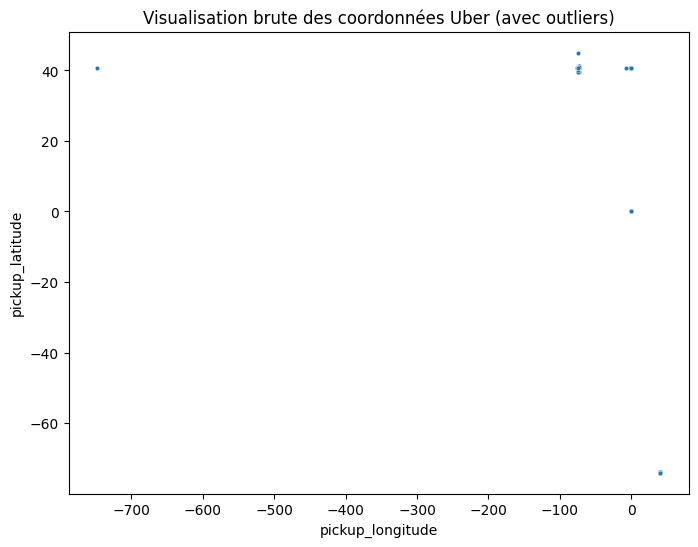

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude', s=10)
plt.title("Visualisation brute des coordonnées Uber (avec outliers)")
plt.show()


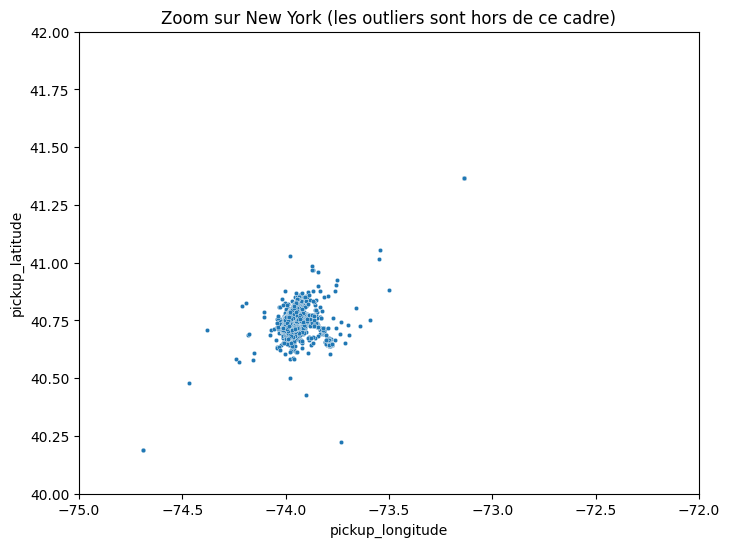

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude', s=10)
plt.xlim(-75, -72)   # limites longitude New York
plt.ylim(40, 42)     # limites latitude New York
plt.title("Zoom sur New York (les outliers sont hors de ce cadre)")
plt.show()


In [35]:
df = df[
    (df['pickup_longitude'] > -75) & (df['pickup_longitude'] < -72) &
    (df['pickup_latitude'] > 40) & (df['pickup_latitude'] < 42)
]


In [37]:
df[
    (df['pickup_longitude'] < -75) | (df['pickup_longitude'] > -72) &
    (df['pickup_latitude'] < 40) | (df['pickup_latitude'] > 42)
].head()


,pickup_longitude,pickup_latitude,hour,day,month,season,cluster


In [40]:

import matplotlib.pyplot as plt
import seaborn as sns

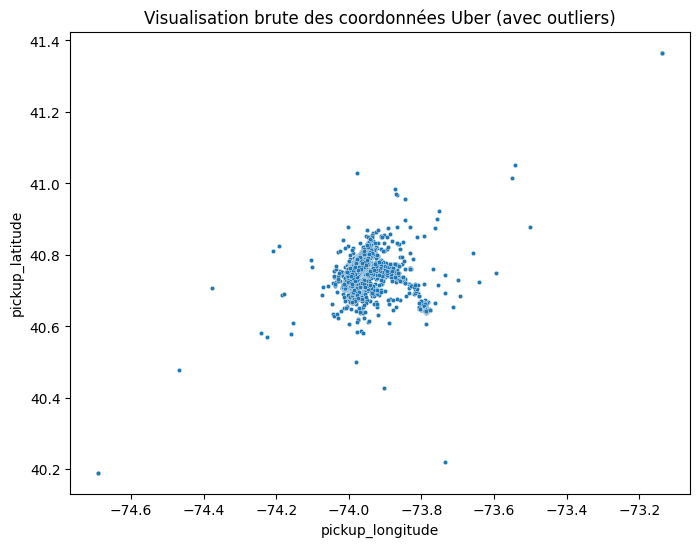

In [39]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude', s=10)
plt.title("Visualisation brute des coordonnées Uber (avec outliers)")
plt.show()


In [45]:
from sklearn.cluster import DBSCAN

In [67]:


X = df[['pickup_longitude', 'pickup_latitude']].values

db = DBSCAN(eps=0.04, min_samples=10).fit(X)
df['cluster'] = db.labels_

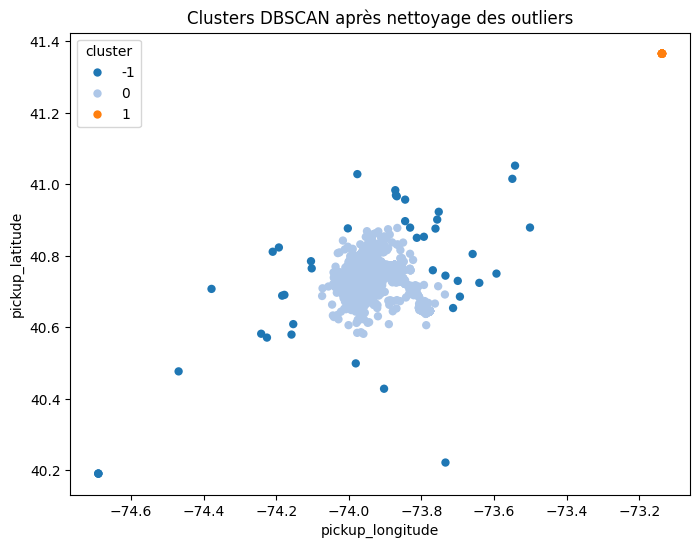

In [68]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude',
                hue='cluster', palette='tab20', linewidth=0)
plt.title("Clusters DBSCAN après nettoyage des outliers")
plt.show()


In [54]:
df[df['cluster'] == -1].info()


<class 'pandas.core.frame.DataFrame'>
Index: 61 entries, 457 to 43500
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  61 non-null     float64
 1   pickup_latitude   61 non-null     float64
 2   hour              61 non-null     int32  
 3   day               61 non-null     int32  
 4   month             61 non-null     int32  
 5   season            61 non-null     object 
 6   cluster           61 non-null     int64  
dtypes: float64(2), int32(3), int64(1), object(1)
memory usage: 3.1+ KB


In [55]:
df[df['cluster'] == 0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 37153 entries, 0 to 44376
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  37153 non-null  float64
 1   pickup_latitude   37153 non-null  float64
 2   hour              37153 non-null  int32  
 3   day               37153 non-null  int32  
 4   month             37153 non-null  int32  
 5   season            37153 non-null  object 
 6   cluster           37153 non-null  int64  
dtypes: float64(2), int32(3), int64(1), object(1)
memory usage: 1.8+ MB


In [56]:
df[df['cluster'] == 1].info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 4992 to 42183
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  16 non-null     float64
 1   pickup_latitude   16 non-null     float64
 2   hour              16 non-null     int32  
 3   day               16 non-null     int32  
 4   month             16 non-null     int32  
 5   season            16 non-null     object 
 6   cluster           16 non-null     int64  
dtypes: float64(2), int32(3), int64(1), object(1)
memory usage: 832.0+ bytes


In [ ]:
df.drop()

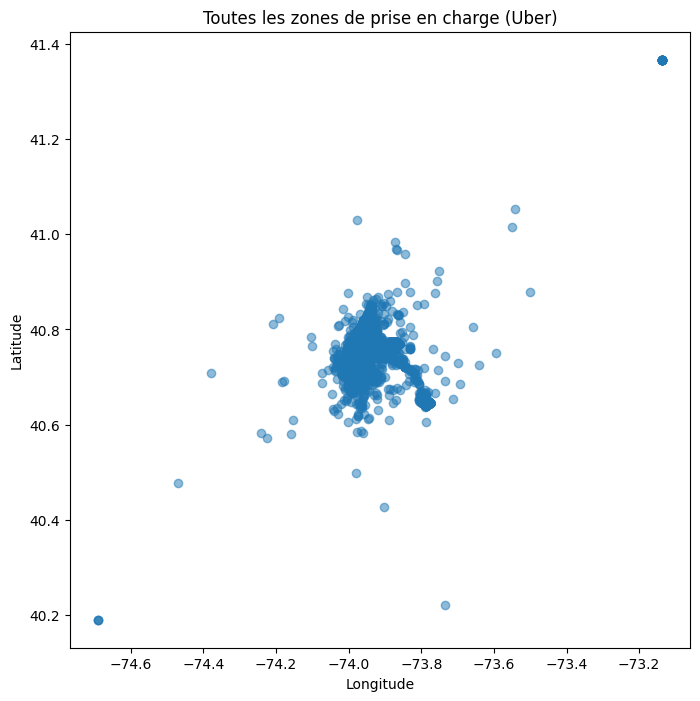

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.scatter(df['pickup_longitude'], df['pickup_latitude'], alpha=0.5)
plt.title("Toutes les zones de prise en charge (Uber)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


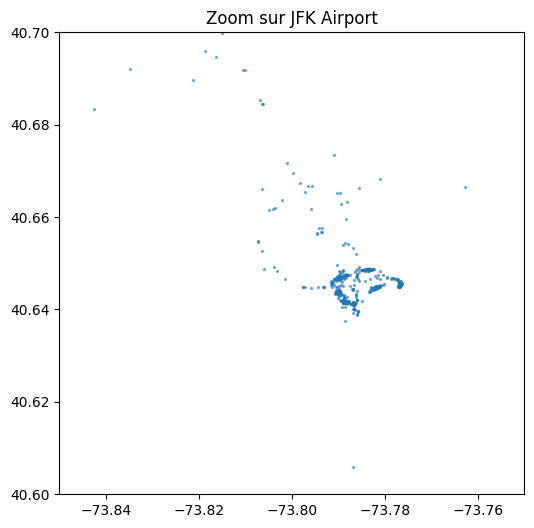

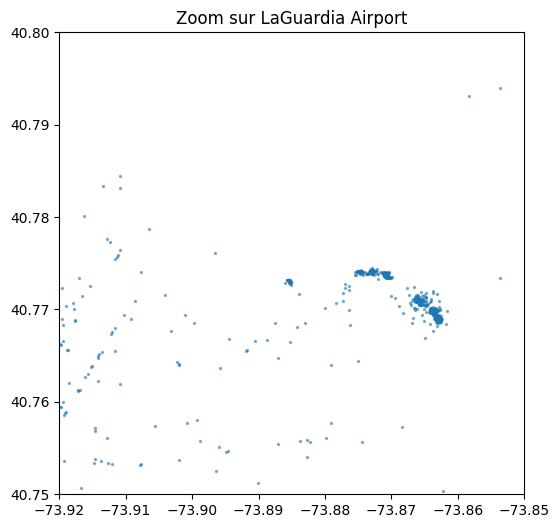

In [74]:
# Zoom sur JFK
plt.figure(figsize=(6,6))
plt.scatter(df['pickup_longitude'], df['pickup_latitude'], s=2, alpha=0.5)
plt.xlim(-73.85, -73.75)  # longitude JFK
plt.ylim(40.6, 40.7)      # latitude JFK
plt.title("Zoom sur JFK Airport")
plt.show()

# Zoom sur LaGuardia
plt.figure(figsize=(6,6))
plt.scatter(df['pickup_longitude'], df['pickup_latitude'], s=2, alpha=0.5)
plt.xlim(-73.92, -73.85)  # longitude LGA
plt.ylim(40.75, 40.8)     # latitude LGA
plt.title("Zoom sur LaGuardia Airport")
plt.show()


In [85]:
df[(df['pickup_longitude'] > -73.81) & (df['pickup_longitude'] < -73.77) & (df['pickup_latitude'] > 40.6) & (df['pickup_latitude'] < 40.7)].info()

<class 'pandas.core.frame.DataFrame'>
Index: 612 entries, 113 to 44217
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  612 non-null    float64
 1   pickup_latitude   612 non-null    float64
 2   hour              612 non-null    int32  
 3   day               612 non-null    int32  
 4   month             612 non-null    int32  
 5   season            612 non-null    object 
 6   cluster           612 non-null    int64  
dtypes: float64(2), int32(3), int64(1), object(1)
memory usage: 31.1+ KB


In [86]:
df[(df['pickup_longitude'] > -73.87) & (df['pickup_longitude'] < -73.86) & (df['pickup_latitude'] > 40.75) & (df['pickup_latitude'] < 40.8)].info()

<class 'pandas.core.frame.DataFrame'>
Index: 360 entries, 104 to 44295
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pickup_longitude  360 non-null    float64
 1   pickup_latitude   360 non-null    float64
 2   hour              360 non-null    int32  
 3   day               360 non-null    int32  
 4   month             360 non-null    int32  
 5   season            360 non-null    object 
 6   cluster           360 non-null    int64  
dtypes: float64(2), int32(3), int64(1), object(1)
memory usage: 18.3+ KB


In [87]:
# === 1. Isoler JFK et LaGuardia ===
jfk = df[(df['pickup_longitude'] > -73.81) & (df['pickup_longitude'] < -73.77) &
         (df['pickup_latitude'] > 40.6) & (df['pickup_latitude'] < 40.7)]

lga = df[(df['pickup_longitude'] > -73.87) & (df['pickup_longitude'] < -73.86) &
         (df['pickup_latitude'] > 40.75) & (df['pickup_latitude'] < 40.8)]

sub_df = pd.concat([jfk, lga])

In [88]:
# === 2. Préparer les données ===
coords = sub_df[['pickup_longitude', 'pickup_latitude']].values

In [89]:
# === 3. Appliquer DBSCAN ===
db = DBSCAN(eps=0.01, min_samples=30).fit(coords)
sub_df['sub_cluster'] = db.labels_

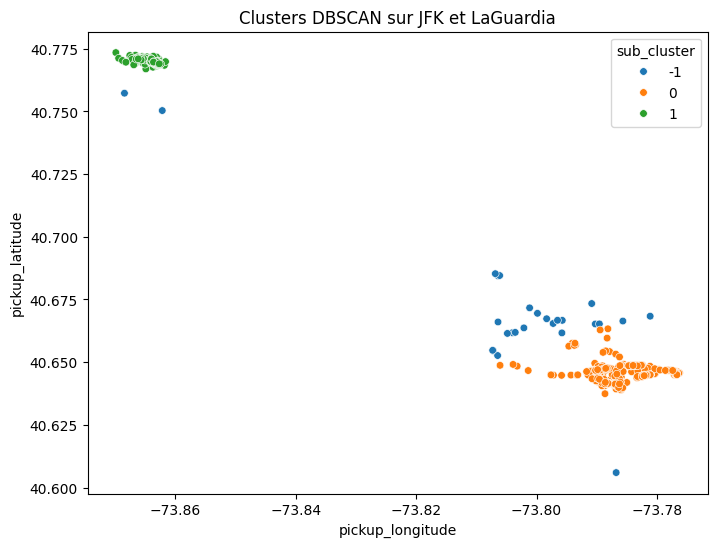

In [90]:
# === 4. Visualisation ===
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=sub_df,
    x='pickup_longitude', y='pickup_latitude',
    hue='sub_cluster', palette='tab10', s=30
)
plt.title("Clusters DBSCAN sur JFK et LaGuardia")
plt.show()